<a href="https://colab.research.google.com/github/Luke-687/Simulating-Chemotaxis--Q-learning-and-Heuristic-/blob/main/Heuristic%20Approach/Model-Data-and-Visuals/Fail-Count-For-Alpha-Gamma).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import matplotlib.pyplot as plt

In [ ]:
#Everything found in the functions below, however only the function for defineScene() and simulate() must be run

#Define gradient values as rewards and as alpha values for future graphing
def defineScene(xS,yS, s): #s is for the steepness of the gradient
  #Arrays of values to be returned for future visualization
  x = []
  y = []
  color = []
  gradient = []
  reward = []

  #Consider a 20x20 grid, a source of chemical at (9.5,9.5)
  for i in range (0,xS+1):
    for j in range (0,yS+1):
      x.append(j)
      y.append(i)
      #Distance based calculations:
      distance = math.sqrt((i-(xS/2))**2+(j-(yS/2))**2)
      #Define reward and gradient values on distance calculation
      if(distance <= 5):
        color.append("green")
        if(not distance<=1):
          gradient.append(1/(distance**s)) #Apply the steepness
          reward.append(10/(distance**s)) #Apply the steepness
        else:
          gradient.append(1)
          reward.append(50)
      else:
        color.append("green")
        gradient.append(0)
        reward.append(-50)
  #Reward values are returned for later use as the means of simulated chemical readings by the agent
  return x, y, gradient, reward


#Function for velocity of subsequent steps based around current position in the x and y axis (using rewards at such positions)
def calculate_velocity(posX, posY, rewards):
  posX = int(posX)
  posY = int(posY)
  #Base calculations upon reward at current x,y (adaptive velocity calculation)
  currentReward = rewards[posX+posY*20]
  if(currentReward<0):
    velocity = 4
  else:
    velocity = 1.5/currentReward
  if(velocity>=4):
    velocity = 4
  if(velocity<=1):
    velocity = 1
  return velocity


#Complex function for the direction of sibsequent steps based on the progression of reward values (past to current rewards, as well as current position)
def calculate_direction(currentX, currentY, pastR, currentR, currentDirection, p): #p exists as a mathematical constant to provide ideal results
  #Define the basic change in the direction
  change=0
  #Essential for later conditionals
  currentPos = math.sqrt((currentX-9.5)**2 + (currentY-9.5)**2)

  #Actual optimized logic for direction calculation:
  if(not currentR==0 and not pastR==0):
    if(currentPos<=5):
      #Provided the agent is within the gradient, position away <=5, then currentR>pastR no matter the situation
      change = 360*(abs(pastR/currentR)**0.59)*((random.choice([-1,1])))

    else:
      if(pastR>currentR): #ensure no issues with the system logic by ensuring the predicted relationship is true
        if(abs(pastR)<abs(currentR)):
          #Provided that pastR and currentR are negative
          change = (180-180*(abs((pastR)/(currentR))**p))*((random.choice([-1,1])))
        else:
          #Provided that pastR and currentR are not both negative
          change = (180-180*(abs((currentR)/(pastR))**p))*((random.choice([-1,1])))

  newDirection = (currentDirection+change)%360
  return (newDirection)


#Establish random motion in the x and y directions at each step from -0.35 to 0.35 units of random change
def brownianMotion():
  result = [0,0]
  xChange = random.random()/4
  yChange = random.random()/4
  for i in range(10):
    xChange+= random.random()/100 * (-1**(random.randint(1,2)))
    yChange+= random.random()/100 * (-1**(random.randint(1,2)))
  result = [xChange, yChange]
  return result


#Simualtion of the agent based around the rules and calculations provided by all function
def simulate (alpha, gamma, xS, yS,steps, steep):
  #Define the initial parameters
  velocity = 4
  direction = random.randint(10,80)
  #Starting position is some (x,y) outside of gradient
  currentX = 0
  currentY = 0
  stepsToBeMade=steps
  xG, yG, gradient, reward = defineScene(xS, yS, steep)
  #This works as an adjustment to the direction recalculation
  p=0.59
  #This works as an adjustment to the alpha and gamma in updated rewards
  test = 3.75

  #Track x,y pos
  x=[]
  y=[]

  pastReward = 0
  for i in range(0, stepsToBeMade):
    #Enter and calculate reward of values which are about to be moved on from
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    x.append(currentX)
    y.append(currentY)

    #Find new position, and new current reward (applu brownian and update rewards for future calculations)
    brownian = brownianMotion()
    changeX = velocity * math.cos(direction*math.pi/180) + brownian[0]
    changeY = velocity * math.sin(direction*math.pi/180) + brownian[1]
    currentX = x[-1] + changeX #past + change in position
    currentY = y[-1] + changeY #past + change in position
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    currentReward = pastReward + test*alpha*(reward[int(currentX+currentY*20)]+test*gamma*(reward[int(currentX+currentY*20)]-pastReward))

    # Redefine velocity and direction for next steps --  refer to functions for better description
    velocity = calculate_velocity(int(currentX), int(currentY), reward)
    direction = calculate_direction(currentX, currentY, pastReward, currentReward, direction, p)
    pastReward = currentReward
  return x,y


In [ ]:
steepness= 0.75

In [ ]:
results = [] #Saved in the form [alpha, gamma, failCount]

for a in range(11):
  for g in range(11):
    alpha = a/10
    gamma = g/10

    failCount = 0 #Count a new number for each alpha-gamma pair
    for simulations in range(1000):
      xSim, ySim = simulate(alpha, gamma, 19,19, 30, steepness)
      outsideGradient = True
      for step in range(len(xSim)):
        distCenter = math.sqrt((xSim[step]-9.5)**2+(ySim[step]-9.5)**2)
        if(distCenter<=5):
          outsideGradient = False
        if(not(outsideGradient) and distCenter>5):
          failCount += 1
          outsideGradient = True
    results.append([alpha, gamma, failCount])


In [ ]:
#Save values for later runs:
from google.colab import drive
import numpy as np

drive.mount('/content/drive')

toSave = np.array(results)
save_path = '/content/drive/MyDrive/heuristicFailCount.npy'

# Save the finalResults array
np.save(save_path, toSave)

Mounted at /content/drive


In [ ]:
#Open final results for later use
results = np.load('/content/drive/MyDrive/heuristicFailCount.npy')

[np.float64(628.0), np.float64(615.0), np.float64(632.0), np.float64(637.0), np.float64(639.0), np.float64(649.0), np.float64(655.0), np.float64(636.0), np.float64(622.0), np.float64(640.0), np.float64(635.0), np.float64(615.0), np.float64(619.0), np.float64(577.0), np.float64(527.0), np.float64(709.0), np.float64(748.0), np.float64(905.0), np.float64(927.0), np.float64(732.0), np.float64(727.0), np.float64(573.0), np.float64(616.0), np.float64(583.0), np.float64(730.0), np.float64(905.0), np.float64(740.0), np.float64(598.0), np.float64(718.0), np.float64(1014.0), np.float64(841.0), np.float64(687.0), np.float64(499.0), np.float64(635.0), np.float64(566.0), np.float64(914.0), np.float64(723.0), np.float64(721.0), np.float64(980.0), np.float64(670.0), np.float64(396.0), np.float64(277.0), np.float64(190.0), np.float64(191.0), np.float64(615.0), np.float64(679.0), np.float64(811.0), np.float64(742.0), np.float64(828.0), np.float64(431.0), np.float64(279.0), np.float64(168.0), np.float64

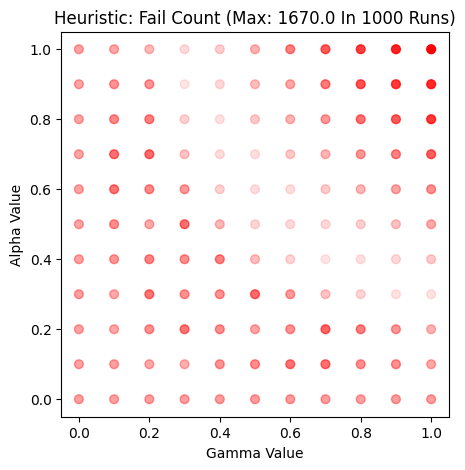

In [ ]:
#Set up results for graphing
alpha = []
gamma = []
failCount = []
for result in range(len(results)):
  alpha.append(results[result][0])
  gamma.append(results[result][1])
  failCount.append(results[result][2])
print(failCount)

#Place the failCount values in the range 0-1 by dividing by the max number of failures and then doing 1- that value to ensure the darker spots are the lower fail counts
maxFail = max(failCount)
for count in range(len(failCount)):
  failCount[count]/=maxFail

#Graph, using failCount as alpha value
plt.figure(figsize=(5, 5))
plt.xlabel("Gamma Value")
plt.ylabel("Alpha Value")
plt.title("Heuristic: Fail Count (Max: "+str(maxFail)+" In 1000 Runs)")
plt.scatter(gamma, alpha, color = 'red', alpha = failCount, s = 40)